In [18]:
!pip install ipywidgets scikit-network --quiet

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import scipy
import sklearn
cwd = Path('.')

In [20]:
data_path = cwd / 'data' / '2025_LoL_esports_match_data_from_OraclesElixir_imputated.csv'
data = pd.read_csv(data_path,index_col=0)
data_len = int(len(data) * 10 / 12)
print(f"matches: {int(data_len/10)}, made up of {data_len} player performances")
print(f"number of columns: {data.shape[1]}")
print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")

matches: 10053, made up of 100530 player performances
number of columns: 165
percentage categorical variables: 13.94%


/tmp/ipykernel_15253/4168379563.py:2: DtypeWarning: Columns (0: league) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path,index_col=0)
/tmp/ipykernel_15253/4168379563.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"percentage categorical variables: {data.select_dtypes(include='object').shape[1] / data.shape[1] * 100:.2f}%")


In [21]:
data = data.drop(data[data["position"] == "team"].index) 

In [22]:
#dropping columns drops international event data as it has a lot of missing data, but we do not need that data for this, so do not drop data
"""
from utils.transform import smart_drop_na
# drop columns with more than a given percentage of missing values
data = smart_drop_na(
    data,
    column_percentage_threshold=0.20,
    row_percentage_threshold=0
)
"""
# but there are a few players with missing playerids, we still need to remove these players for our graph mining as we use the playerids to describe the players
missing_playerids = data[data["playerid"].isna()]
missing_players = missing_playerids["playername"].unique()
games_with_missing_playerids = data[data["gameid"].isin(missing_playerids["gameid"].unique())] 
print(f"there are {len(missing_playerids)} player performances without an associated playerid and {len(missing_players)} unique player names associated with those performances, we remove all of these")
data = data.drop(games_with_missing_playerids.index)


there are 1803 player performances without an associated playerid and 237 unique player names associated with those performances, we remove all of these


In [23]:
uniq_player_ids = data["playerid"].unique()
print(len(uniq_player_ids))
playerid_to_adj_index = dict(zip(uniq_player_ids, range(len(uniq_player_ids))))
adj_index_to_playerid = dict(zip(range(len(uniq_player_ids)), uniq_player_ids))
adj_matrix = np.zeros((len(uniq_player_ids), len(uniq_player_ids)))

2567


In [24]:
# For each playerid, print the number of different leagues they played in:
data.groupby("playerid")["league"].nunique().value_counts()

league
1    1536
2     653
3     257
4      92
5      27
6       2
Name: count, dtype: int64

In [25]:
for i in tqdm(range(0, len(data), 10)):
    player_ids = []
    for j in range(10):
        player_ids.append(data.iloc[i + j]["playerid"])
    
    for p1 in player_ids:
        for p2 in player_ids:
            adj_matrix[playerid_to_adj_index[p1], playerid_to_adj_index[p2]] = 1

  0%|          | 0/9691 [00:00<?, ?it/s]

In [26]:
for j in range(adj_matrix.shape[0]):
    adj_matrix[j,j] = 0

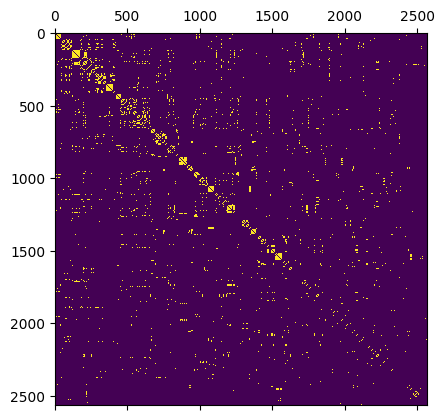

In [27]:
plt.matshow(adj_matrix)

In [ ]:
from sknetwork.clustering import Louvain
from sklearn.manifold import SpectralEmbedding, spectral_embedding
from sklearn.cluster import KMeans, DBSCAN, OPTICS
from sklearn.mixture import GaussianMixture

n_clusters = 45

## Simple clustering on adj matrix
#clustering = sklearn.cluster.spectral_clustering(adj_matrix, n_clusters=n_clusters)
#clustering = Louvain().fit_predict(adj_matrix)

# Embedding then clustering
#embs = SpectralEmbedding(n_components=32).fit_transform(adj_matrix)
embs = spectral_embedding(adj_matrix, n_components=n_clusters, random_state=1, drop_first=False)
# embs = np.load(cwd / "random_walk_embeddings(1).npy")

clustering = KMeans(n_clusters=n_clusters, n_init=10).fit(embs).labels_
#clustering = DBSCAN(eps=0.003, min_samples=1).fit(embs).labels_
#clustering = OPTICS(min_samples=5, xi=0.05, min_cluster_size=0.05).fit(embs).labels_
#clustering = GaussianMixture(n_components=n_clusters, n_init=1).fit(embs).predict(embs)

print(len(np.unique(clustering)))

45


45
Cluster 0: 10 players
Cluster 1: 68 players
Cluster 2: 59 players
Cluster 3: 10 players
Cluster 4: 6 players
Cluster 5: 113 players
Cluster 6: 7 players
Cluster 7: 6 players
Cluster 8: 9 players
Cluster 9: 7 players
Cluster 10: 5 players
Cluster 11: 7 players
Cluster 12: 6 players
Cluster 13: 21 players
Cluster 14: 82 players
Cluster 15: 24 players
Cluster 16: 21 players
Cluster 17: 63 players
Cluster 18: 10 players
Cluster 19: 72 players
Cluster 20: 76 players
Cluster 21: 89 players
Cluster 22: 93 players
Cluster 23: 44 players
Cluster 24: 69 players
Cluster 25: 153 players
Cluster 26: 84 players
Cluster 27: 53 players
Cluster 28: 129 players
Cluster 29: 77 players
Cluster 30: 73 players
Cluster 31: 75 players
Cluster 32: 53 players
Cluster 33: 191 players
Cluster 34: 98 players
Cluster 35: 76 players
Cluster 36: 97 players
Cluster 37: 44 players
Cluster 38: 59 players
Cluster 39: 81 players
Cluster 40: 67 players
Cluster 41: 80 players
Cluster 42: 11 players
Cluster 43: 6 players


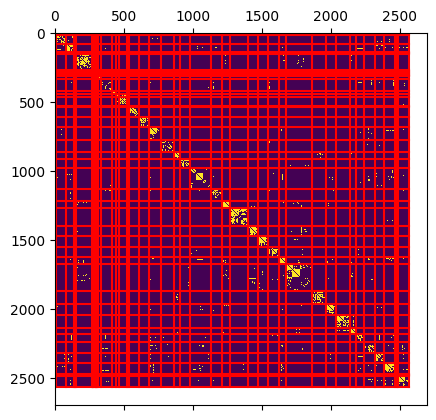

nmi_regions: 0.5605077797386566
nmi_continents: 0.5174334566109937
nmi_leagues: 0.889059574316759
silhouette_score: 0.5832522165048128


In [ ]:
from utils.visualize import plot_adj_matrix_sorted_by_clustering
from sklearn.metrics import normalized_mutual_info_score
from utils.score import score_regions, score_continents, score_leagues
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import silhouette_score

plot_adj_matrix_sorted_by_clustering(adj_matrix, clustering)

score_fn = normalized_mutual_info_score
print("nmi_regions:", score_regions(clustering, uniq_player_ids, data, score_fn))
print("nmi_continents:", score_continents(clustering, uniq_player_ids, data, score_fn))
print("nmi_leagues:", score_leagues(clustering, uniq_player_ids, data, score_fn))

score_fn = adjusted_rand_score
print("ari_regions:", score_regions(clustering, uniq_player_ids, data, score_fn))
print("ari_continents:", score_continents(clustering, uniq_player_ids, data, score_fn))
print("ari_leagues:", score_leagues(clustering, uniq_player_ids, data, score_fn))

silhouette_score_value = silhouette_score(embs, clustering)
print("silhouette_score between embeddings and clustering (more of a metric of the clustering aglorithm on top of embs):", silhouette_score_value)

/tmp/ipykernel_15253/1530776997.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_labels = plt.cm.get_cmap('turbo', len(np.unique(clustering)))(clustering)


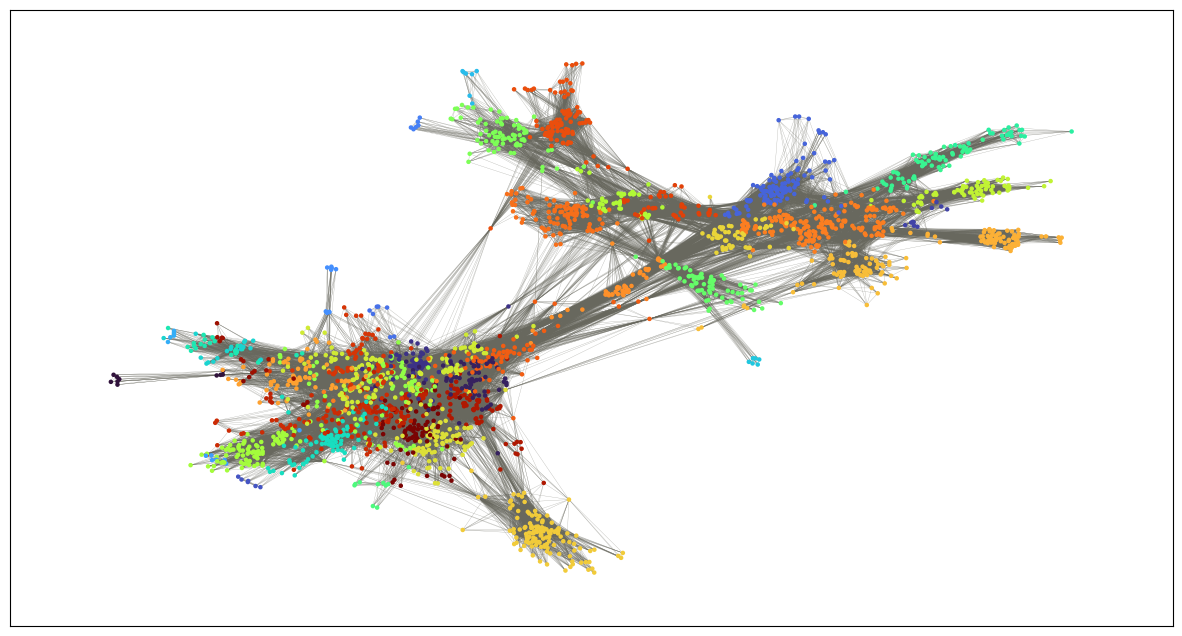

In [184]:
import networkx as nx
plt.figure(figsize=(15,8))
G = nx.from_numpy_array(adj_matrix)
layout = nx.spring_layout(G, seed=1)
color_labels = plt.cm.get_cmap('turbo', len(np.unique(clustering)))(clustering)
nx.draw_networkx_nodes(G, layout, node_size=5, node_color=color_labels)
nx.draw_networkx_edges(G, layout, width=0.2, alpha=0.6, edge_color = "#68685e")